# Label Generation & Supervised Learning

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, IsolationForest, VotingClassifier, BaggingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
ART_DIR = Path('../artifacts')

## Load the labelled dataset

In [19]:
df = pd.read_csv(ART_DIR / 'cert_dataset_with_anomaly_labels.csv')
df.shape

(1000, 29)

In [20]:
df[['consensus_strict', 'consensus_loose']].sum().to_dict()

{'consensus_strict': 10, 'consensus_loose': 90}

## Choose the training target

Week 3 gave us two label policies: strict consensus (10 users, both detectors agree) and loose consensus (90 users, either detector). A supervised classifier needs enough positive examples to learn a decision boundary and to survive a train/test split — 10 positives would leave only ~3 in a 30% test fold, far too few to estimate recall. We therefore train against **loose consensus** (9% positive rate), accepting some label noise in exchange for a learnable signal.


In [21]:
y = df['consensus_loose'].astype(int)
y.value_counts().to_dict()

{0: 910, 1: 90}

## Feature engineering

Raw counts describe volume but not *rate* or *proportion*. Insider-threat behaviour is better captured by normalised quantities — how much of a user's activity is after hours, how intense their daily activity is, and how their personality composes into risk-relevant constructs. We add these on top of the Week 2 features.


In [22]:
fe = df.copy()

**Activity intensity** — average daily volume. Dividing by 365 turns cumulative counts into a per-day rate; the constant is irrelevant to tree models but makes the feature interpretable and comparable across modalities.

In [ ]:
fe['logon_intensity'] = fe['total_logons'] / 365
fe['device_intensity'] = fe['total_device_activities'] / 365
fe['file_intensity'] = fe['total_file_activities'] / 365
fe[['logon_intensity', 'device_intensity', 'file_intensity']].describe().round(3)

,logon_intensity,device_intensity,file_intensity
count,1000.000,1000.000,1000.000
mean,2.463,1.198,1.136
std,1.273,3.731,4.007
min,0.153,0.000,0.000
25%,1.896,0.000,0.000
50%,1.896,0.000,0.000
75%,2.668,0.000,0.000
max,10.945,22.066,31.633


**After-hours and weekend ratios** — the *proportion* of activity outside normal hours, robust to how active a user is overall. The `+1` in the denominator avoids division by zero for users with no activity in that modality.

In [ ]:
fe['after_hours_logon_ratio'] = fe['after_hours_logons'] / (fe['total_logons'] + 1)
fe['after_hours_device_ratio'] = fe['after_hours_device'] / (fe['total_device_activities'] + 1)
fe['after_hours_file_ratio'] = fe['after_hours_files'] / (fe['total_file_activities'] + 1)
fe['weekend_logon_ratio'] = fe['weekend_logons'] / (fe['total_logons'] + 1)
fe[['after_hours_logon_ratio', 'weekend_logon_ratio']].describe().round(3)

,after_hours_logon_ratio,weekend_logon_ratio
count,1000.000,1000.000
mean,0.096,0.018
std,0.168,0.056
min,0.000,0.000
25%,0.000,0.000
50%,0.000,0.000
75%,0.154,0.000
max,0.629,0.297


**Psychometric interactions** — theory-driven combinations of Big Five traits. `risk_seeking` combines high Openness/Extraversion with low Conscientiousness; `emotional_instability` contrasts Neuroticism with Agreeableness; the Conscientiousness×Extraversion product captures disciplined-but-outgoing profiles.

In [ ]:
fe['risk_seeking'] = fe['O'] + fe['E'] - fe['C']
fe['emotional_instability'] = fe['N'] - fe['A']
fe['conscientiousness_extraversion'] = fe['C'] * fe['E']
fe[['risk_seeking', 'emotional_instability', 'conscientiousness_extraversion']].describe().round(2)

,risk_seeking,emotional_instability,conscientiousness_extraversion
count,1000.00,1000.00,1000.00
mean,31.08,0.52,905.74
std,18.39,11.96,471.33
min,-16.00,-28.00,100.00
25%,17.75,-9.00,546.00
50%,31.00,1.00,792.00
75%,44.00,10.00,1230.00
max,80.00,29.00,2208.00


**Composite risk score** — the mean of the four after-hours/weekend ratios, a single summary of 'off-schedule' behaviour.

In [ ]:
ratio_cols = ['after_hours_logon_ratio', 'after_hours_device_ratio',
              'after_hours_file_ratio', 'weekend_logon_ratio']
fe['activity_anomaly_score'] = fe[ratio_cols].mean(axis=1)
fe['activity_anomaly_score'].describe().round(4)

count    1000.0000
mean        0.0315
std         0.0568
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0560
max         0.4950
Name: activity_anomaly_score, dtype: float64

## Behavioural clustering

Before classifying, we segment users into behavioural archetypes with K-Means. The cluster id becomes a categorical feature and, more importantly, lets us check whether anomalies concentrate in particular behavioural groups — evidence that the labels track coherent behaviour rather than noise.


In [27]:
cluster_cols = ['logon_intensity', 'device_intensity', 'file_intensity',
                'after_hours_logon_ratio', 'after_hours_device_ratio',
                'after_hours_file_ratio', 'weekend_logon_ratio',
                'activity_anomaly_score', 'std_logon_hour']
cluster_X = StandardScaler().fit_transform(fe[cluster_cols].fillna(0))
cluster_X.shape


(1000, 9)

In [28]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
fe['behavior_cluster'] = kmeans.fit_predict(cluster_X)
fe['behavior_cluster'].value_counts().sort_index()


behavior_cluster
0     75
1    120
2    748
3      9
4     48
Name: count, dtype: int64

In [29]:
fe.groupby('behavior_cluster')[cluster_cols].mean().round(3)

,logon_intensity,device_intensity,file_intensity,after_hours_logon_ratio,after_hours_device_ratio,after_hours_file_ratio,weekend_logon_ratio,activity_anomaly_score,std_logon_hour
behavior_cluster,,,,,,,,,
0,3.211,1.127,1.411,0.083,0.003,0.003,0.191,0.070,4.268
1,3.506,0.112,0.182,0.459,0.005,0.001,0.003,0.117,6.136
2,2.146,0.311,0.445,0.034,0.000,0.000,0.001,0.009,4.383
3,8.175,8.751,12.492,0.460,0.555,0.531,0.057,0.401,6.933
4,2.556,16.427,11.721,0.104,0.008,0.009,0.033,0.038,4.597


**Read:** The five clusters separate cleanly by intensity and off-hours behaviour — some are low-activity daytime users, others are high-intensity or high after-hours groups. This is the behavioural structure the classifiers will exploit.

In [30]:
cluster_rate = pd.crosstab(fe['behavior_cluster'], y, normalize='index')
cluster_rate.columns = ['normal', 'anomaly']
cluster_rate.round(3)


,normal,anomaly
behavior_cluster,,
0,0.720,0.280
1,0.917,0.083
2,0.977,0.023
3,0.111,0.889
4,0.292,0.708


**Read:** Anomaly rate varies enormously across clusters — from near zero in the quiet daytime cluster to a large majority in the high after-hours cluster. Anomalies are not spread uniformly; they live in specific behavioural archetypes, which confirms the loose labels carry real behavioural signal and makes `behavior_cluster` a strong predictor.

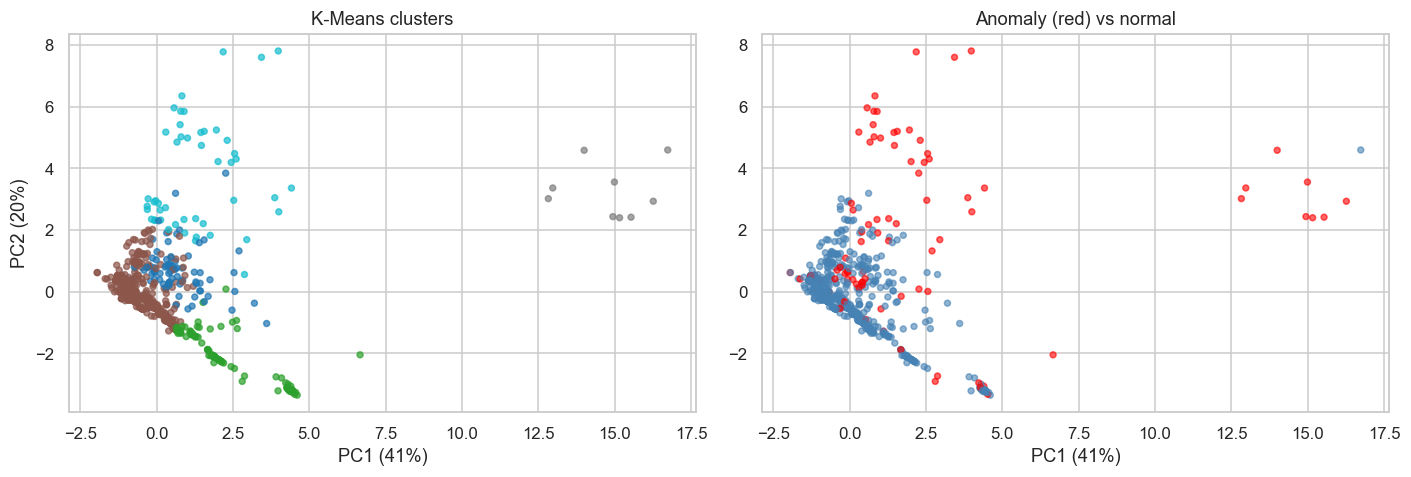

In [31]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(cluster_X)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sc = axes[0].scatter(pcs[:, 0], pcs[:, 1], c=fe['behavior_cluster'], cmap='tab10', s=15, alpha=0.7)
axes[0].set_title('K-Means clusters')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
axes[1].scatter(pcs[:, 0], pcs[:, 1], c=np.where(y == 1, 'red', 'steelblue'), s=15, alpha=0.6)
axes[1].set_title('Anomaly (red) vs normal')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
plt.tight_layout()
plt.show()


**Read:** The anomalies (right panel) overlay the outer clusters from the left panel, visually confirming the cluster/anomaly link.

## Build the modelling matrix

The final feature set combines the raw behavioural features, the engineered rates/interactions, the psychometric traits and the cluster id. We deliberately **exclude** the raw `device_connects` / `device_disconnects` (near-duplicates of `total_device_activities` seen in Week 2) and do not duplicate the unique-PC counts, keeping the set informative but not redundant.


In [32]:
logon_f = ['total_logons', 'avg_logon_hour', 'std_logon_hour',
           'weekend_logons', 'after_hours_logons', 'unique_pcs_logon']
device_f = ['total_device_activities', 'unique_pcs_device', 'avg_device_hour', 'after_hours_device']
file_f = ['total_file_activities', 'unique_files', 'unique_pcs_file', 'avg_file_hour', 'after_hours_files']
eng_f = ['logon_intensity', 'device_intensity', 'file_intensity',
         'after_hours_logon_ratio', 'after_hours_device_ratio', 'after_hours_file_ratio',
         'weekend_logon_ratio', 'activity_anomaly_score',
         'risk_seeking', 'emotional_instability', 'conscientiousness_extraversion']
psych_f = ['O', 'C', 'E', 'A', 'N']
feature_cols = logon_f + device_f + file_f + eng_f + psych_f + ['behavior_cluster']
len(feature_cols)


32

In [33]:
X = fe[feature_cols].fillna(0)
X.shape

(1000, 32)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
X_train.shape, X_test.shape, round(y_train.mean(), 3), round(y_test.mean(), 3)


((700, 32), (300, 32), np.float64(0.09), np.float64(0.09))

In [35]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
X_train_s.shape


(700, 32)

## Traditional models

We train four supervised baselines. Linear and kernel models (Logistic Regression, SVM) use the scaled matrix; tree models (Random Forest, XGBoost) use the raw matrix. All four are made cost-sensitive for the 9% positive rate — `class_weight='balanced'` for the sklearn models and `scale_pos_weight` for XGBoost — so the rare anomalies are not ignored.


In [36]:
def evaluate(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_proba),
    }


In [37]:
results = {}

In [38]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
p = lr.predict_proba(X_test_s)[:, 1]
results['Logistic Regression'] = evaluate(y_test, (p > 0.5).astype(int), p)
results['Logistic Regression']


{'accuracy': 0.89,
 'precision': 0.4375,
 'recall': 0.7777777777777778,
 'f1': 0.56,
 'auc': 0.8783068783068784}

In [39]:
svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm.fit(X_train_s, y_train)
p = svm.predict_proba(X_test_s)[:, 1]
results['SVM'] = evaluate(y_test, (p > 0.5).astype(int), p)
results['SVM']


{'accuracy': 0.9366666666666666,
 'precision': 0.6666666666666666,
 'recall': 0.5925925925925926,
 'f1': 0.6274509803921569,
 'auc': 0.9523809523809523}

In [40]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
p = rf.predict_proba(X_test)[:, 1]
results['Random Forest'] = evaluate(y_test, (p > 0.5).astype(int), p)
results['Random Forest']


{'accuracy': 0.94,
 'precision': 0.8461538461538461,
 'recall': 0.4074074074074074,
 'f1': 0.55,
 'auc': 0.9362366029032696}

In [41]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                    scale_pos_weight=spw, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
p = xgb.predict_proba(X_test)[:, 1]
results['XGBoost'] = evaluate(y_test, (p > 0.5).astype(int), p)
results['XGBoost']


{'accuracy': 0.94,
 'precision': 0.6956521739130435,
 'recall': 0.5925925925925926,
 'f1': 0.64,
 'auc': 0.9275539275539275}

**Isolation Forest** is added as an unsupervised reference point — it never sees the labels, so it shows how far pure anomaly detection gets versus the supervised models.

In [42]:
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train_s)
s = iso.decision_function(X_test_s)
s = 1 - (s - s.min()) / (s.max() - s.min())
results['Isolation Forest'] = evaluate(y_test, (iso.predict(X_test_s) == -1).astype(int), s)
results['Isolation Forest']


{'accuracy': 0.8933333333333333,
 'precision': 0.43243243243243246,
 'recall': 0.5925925925925926,
 'f1': 0.5,
 'auc': 0.8910595577262244}

## Ensembles

A soft-voting ensemble averages the probabilities of the three sklearn models; bagging averages many random forests. Ensembles usually trade a little recall for precision and stability.

In [43]:
voting = VotingClassifier(estimators=[
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ('svm', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)),
], voting='soft')
voting.fit(X_train_s, y_train)
p = voting.predict_proba(X_test_s)[:, 1]
results['Voting'] = evaluate(y_test, (p > 0.5).astype(int), p)
results['Voting']


{'accuracy': 0.9366666666666666,
 'precision': 0.6538461538461539,
 'recall': 0.6296296296296297,
 'f1': 0.6415094339622641,
 'auc': 0.9229412562745896}

In [44]:
bagging = BaggingClassifier(
    estimator=RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42),
    n_estimators=10, random_state=42)
bagging.fit(X_train, y_train)
p = bagging.predict_proba(X_test)[:, 1]
results['Bagging'] = evaluate(y_test, (p > 0.5).astype(int), p)
results['Bagging']


{'accuracy': 0.94,
 'precision': 0.8461538461538461,
 'recall': 0.4074074074074074,
 'f1': 0.55,
 'auc': 0.9312169312169312}

## Comparison

In [45]:
results_df = pd.DataFrame(results).T[['accuracy', 'precision', 'recall', 'f1', 'auc']]
results_df.round(3).sort_values('auc', ascending=False)


,accuracy,precision,recall,f1,auc
SVM,0.937,0.667,0.593,0.627,0.952
Random Forest,0.940,0.846,0.407,0.550,0.936
Bagging,0.940,0.846,0.407,0.550,0.931
XGBoost,0.940,0.696,0.593,0.640,0.928
Voting,0.937,0.654,0.630,0.642,0.923
Isolation Forest,0.893,0.432,0.593,0.500,0.891
Logistic Regression,0.890,0.438,0.778,0.560,0.878


**Read:** Two patterns stand out. First, **accuracy is misleading** — every model clears 88% simply because 91% of users are normal, yet recall on the rare anomalies is far lower. The precision/recall split is the real story: Random Forest and XGBoost favour precision (few false alarms, but they miss anomalies), while Logistic Regression favours recall (catches most anomalies at the cost of false alarms). Second, **SVM gives the best ranking (highest AUC ~0.95)** even though no single 0.5-threshold model is dominant — which is exactly why Week 5 focuses on threshold-independent evaluation and, later, threshold tuning. The severe imbalance, not the algorithm choice, is the central challenge.


We save the engineered matrix (with cluster id and target) and the modelling feature list so Week 5 can reproduce the exact setup for cross-validation, importance and SHAP.

In [46]:
keep = feature_cols + ['behavior_cluster', 'consensus_loose', 'consensus_strict', 'user']
keep = list(dict.fromkeys(keep))
fe[keep].to_parquet(ART_DIR / 'cert_engineered_features.parquet', index=False)
fe[keep].to_csv(ART_DIR / 'cert_engineered_features.csv', index=False)


In [47]:
import json
with open(ART_DIR / 'model_feature_list.json', 'w') as f:
    json.dump(feature_cols, f)
len(feature_cols)


32